In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
############################################################

In [3]:
config = load_config(overrides=['dataset=mouse_brain'])
OmegaConf.set_struct(config, False)

config.classifier.num_layers = 2
config.classifier.hidden_dim = 128
config.classifier.epsilon = 0.05

In [18]:
path = "data"
tissue = config.tissue
pc_dim = config.pc_dim
use_paga = config.use_paga
paga_threshold = config.paga_threshold

BLOOD = [ "Blood progenitors 1",
            "Blood progenitors 2",
            "Haematoendothelial progenitors",
            "Erythroid1",
            "Erythroid2",
            "Erythroid3"]

BRAIN = [
            "Rostral neurectoderm",
            "Forebrain/Midbrain/Hindbrain",
            "Spinal cord",
            "Caudal neurectoderm",
            "Caudal epiblast",
            "NMP",
            "Neural crest"
            ]
cache_file = os.path.join(path, "atlas", "mouse_preprocessed.h5ad")
if os.path.exists(cache_file):
    print("Loading cached preprocessed mouse data...")
    adata = sc.read(cache_file)

adata.obs['cell_type'] = adata.obs['celltype'].astype(str)

stage_to_num = {
    'E6.5': 6.5, 'E6.75': 6.75, 'E7.0': 7.0, 'E7.25': 7.25,
    'E7.5': 7.5, 'E7.75': 7.75, 'E8.0': 8.0, 'E8.25': 8.25, 'E8.5': 8.5
}
adata.obs['timepoint'] = adata.obs['stage'].map(stage_to_num).astype(float)

print(adata[adata.obs['cell_type'] == "Caudal epiblast"].shape)

# SUBSET TO TISSUE
if tissue == "brain":
    cell_list = BRAIN
    root_node = ["NMP", "Caudal epiblast"]
elif tissue == "blood":
    cell_list = BLOOD
    root_node ="Haematoendothelial progenitors"
else:
    cell_list = None
    root_node = None

adata = adata[adata.obs['cell_type'].isin(cell_list)].copy()

adata.obs['cell_type'] = adata.obs['cell_type'].astype('category').cat.remove_unused_categories()

# PCA
sc.tl.pca(adata, n_comps=pc_dim, mask_var=None)
adata.uns['std'] = np.ones((1, pc_dim))

# Tree: always use PAGA for mouse 
if use_paga:
    print("using paga")

adj = run_paga_tree(adata, 'cell_type', threshold=paga_threshold, root_node=root_node) 


Loading cached preprocessed mouse data...
(2252, 2000)
using paga


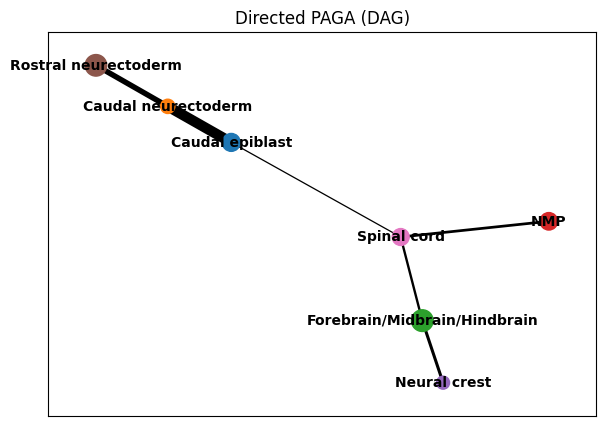

In [19]:
original_conn = adata.uns['paga']['connectivities'].copy()
adata.uns['paga']['connectivities'] = adata.uns['paga']['connectivities_dag']

sc.pl.paga(adata, threshold=config.paga_threshold, title='Directed PAGA (DAG)')
adata.uns['paga']['connectivities'] = original_conn

In [ ]:
   
adata = incorporate_tree(adata, adj, 'cell_type')

In [5]:
# adata[adata.obs['timepoint'] == 8.0].obs['sample'].unique().tolist()

In [6]:
### SETTINGS ###

adata = process_data(pc_dim=config.pc_dim, 
                     t0_index=config.t0_index,
                     t1_index=config.t1_index,
                     data=config.data, 
                     use_paga=config.use_paga,
                     paga_threshold=config.paga_threshold,
                     tissue=config.tissue)

print(adata.obs['cell_type'].nunique())

timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config.num_classes = adata.obs['cell_type'].nunique()

print(config.t0_index)
print(config.t1_index)

Loading cached preprocessed mouse data...
using paga
6
1
7


/home/azweig/projects/finfm/utils/lineage.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [7]:
adata

AnnData object with n_obs × n_vars = 14925 × 2000
    obs: 'cell', 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'n_genes', 'cell_type', 'timepoint', 'cell_type_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'std', 'neighbors', 'paga', 'cell_type_sizes', 'stoi', 'itos', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [8]:
for c in adata.obs['cell_type'].unique():
    print(c)

Rostral neurectoderm
Caudal neurectoderm
Forebrain/Midbrain/Hindbrain
Spinal cord
NMP
Neural crest


In [7]:
adata.obs["timepoint"].unique()

array([7.5 , 6.75, 7.75, 7.  , 8.  , 8.5 , 7.25, 8.25])

In [8]:
timepoints

[6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5]

In [9]:
print(config.t0_index, config.t1_index)

1 4


In [10]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]

print(t0, t1)

7.0 7.75


In [11]:
adata

View of AnnData object with n_obs × n_vars = 3379 × 2000
    obs: 'cell', 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'n_genes', 'cell_type', 'timepoint', 'cell_type_one_hot'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'std', 'neighbors', 'paga', 'cell_type_sizes', 'stoi', 'itos', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

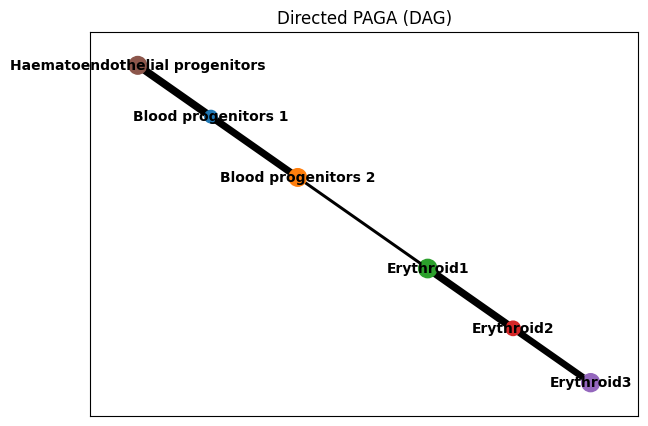

In [14]:
sc.pl.paga(adata, threshold=0.2, title='Directed PAGA (DAG)')

In [ ]:
# # Explore cell types and stages
# print("Cell types:")
# for ct in sorted(adata.obs['cell_type'].unique()):
#     n = (adata.obs['cell_type'] == ct).sum()
#     print(f"  {ct}: {n}")

# print(f"\nStages:")
# for t in timepoints:
#     n = (adata.obs['timepoint'] == t).sum()
#     print(f"  {t}: {n}")

In [ ]:
# # Visualize tree structure
# itos = adata.uns['itos']
# N = adata.uns['tree'].shape[0]
# print("Tree edges:")
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(f"  {itos[i]} -> {itos[j]}")

In [ ]:
# #CFM
# config.metric = "cfm"
# config.no_learning = True
# config.metric_max_epochs = 2

In [ ]:
#CFM + Finsler
# config.metric = "cfm"

# config.finsler.use = True
# config.finsler.lamb = 0.5
# config.balance_classes = False
# config.metric_max_epochs = 2

In [ ]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [ ]:
#MFM
config.metric = "mfm"

config.mfm.K = 150
config.mfm.kappa = 1.5
config.mfm.epsilon = 1e-1
config.finsler.use = False
config.finsler.lamb = 0.0

In [ ]:
#MFM + Finsler
config.metric = "mfm"

config.mfm.K = 150
config.mfm.kappa = 1.5
config.mfm.epsilon = 1e-1

# config.finsler.use = True
# config.finsler.lamb = 0.5

In [ ]:
adata

In [ ]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [ ]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

In [ ]:
remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [ ]:
# MFM + Finlser
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

In [ ]:
# MFM
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

In [ ]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]

fig, axes = plt.subplots(10, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=plt.cm.tab20.colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(1, 0.5),
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()

In [ ]:
start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model.classify(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model.classify(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(10):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")

In [ ]:
paths.shape

In [ ]:
#3->8
#PCA on everything

#CFM: 7.8333
#CFM + Finsler: 8.1958

#MFM-Euc: 
#MFM: 7.5061
#MFM + Finsler: 7.6789